In [6]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, utils
from torchvision.models import inception_v3, resnet18
from collections import Counter
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy import linalg
import os
#os.remove("D:/PRE2023 2025/cifar10_revision_2026/cifar10_resnet18.pth")
# pytorch-fid / torchmetrics（可选，保留你原来的逻辑）

import os, shutil
for p in [
    f"{BASE_PATH}/generator_gaussian.pth",
    f"{BASE_PATH}/discriminator_gaussian.pth",
    f"{BASE_PATH}/logs_gaussian",
    f"{BASE_PATH}/images_fake_gaussian",
    f"{BASE_PATH}/samples_gaussian",
]:
    if os.path.isdir(p):
        shutil.rmtree(p)
    elif os.path.isfile(p):
        os.remove(p)


try:
    from pytorch_fid import fid_score
    PYTORCH_FID_AVAILABLE = True
except ImportError:
    PYTORCH_FID_AVAILABLE = False

try:
    from torchmetrics.image.fid import FrechetInceptionDistance
    from torchmetrics.image.inception import InceptionScore
    TORCHMETRICS_AVAILABLE = True
except ImportError:
    TORCHMETRICS_AVAILABLE = False

BASE_PATH = "D:/PRE2023 2025/cifar10_revision_2026"
os.makedirs(BASE_PATH, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer',
                   'dog','frog','horse','ship','truck']

# ================================================================
# 1. 四种激活函数（统一 log_sigma 参数化）
# ================================================================
class LogisticCDF(nn.Module):
    def __init__(self, init_sigma=1.0):
        super().__init__()
        self.log_sigma = nn.Parameter(torch.tensor(np.log(init_sigma), dtype=torch.float32))
    @property
    def sigma(self):
        return torch.exp(self.log_sigma)
    def forward(self, x):
        z = torch.clamp(x / self.sigma, -30, 30)
        return torch.sigmoid(z)

class GaussianCDF(nn.Module):
    def __init__(self, init_sigma=1.0):
        super().__init__()
        self.log_sigma = nn.Parameter(torch.tensor(np.log(init_sigma), dtype=torch.float32))
    @property
    def sigma(self):
        return torch.exp(self.log_sigma)
    def forward(self, x):
        z = torch.clamp(x / self.sigma, -10.0, 10.0)
        out = 0.5 * (1.0 + torch.erf(z / np.sqrt(2.0)))
        return out.clamp(1e-7, 1 - 1e-7)

class LaplaceCDF(nn.Module):
    def __init__(self, init_sigma=1.0):
        super().__init__()
        self.log_sigma = nn.Parameter(torch.tensor(np.log(init_sigma), dtype=torch.float32))
    @property
    def sigma(self):
        return torch.exp(self.log_sigma)
    def forward(self, x):
        sigma = self.sigma
        out = torch.where(
            x < 0,
            0.5 * torch.exp(torch.clamp(x / sigma, min=-30)),
            1 - 0.5 * torch.exp(torch.clamp(-x / sigma, min=-30))
        )
        return out.clamp(1e-7, 1 - 1e-7)

def make_activation(name):
    if name == 'sigmoid':
        return nn.Sigmoid()
    if name == 'logistic':
        return LogisticCDF(init_sigma=1.0)
    if name == 'gaussian':
        return GaussianCDF(init_sigma=1.0)
    if name == 'laplace':
        return LaplaceCDF(init_sigma=1.0)
    raise ValueError(name)

# ================================================================
# 2. DCGAN 生成器 / 判别器
# ================================================================
class CIFAR10Generator(nn.Module):
    def __init__(self, latent_dim=100, ngf=64):
        super().__init__()
        self.latent_dim = latent_dim
        self.main = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, ngf*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2, 3, 4, 2, 1, bias=False),
            nn.Tanh(),
        )
    def forward(self, z):
        return self.main(z.view(z.size(0), z.size(1), 1, 1))

class CIFAR10Discriminator(nn.Module):
    def __init__(self, activation_name='sigmoid', ndf=64):
        super().__init__()
        self.activation_name = activation_name
        self.main = nn.Sequential(
            nn.Conv2d(3, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*4), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf*4, 1, 4, 1, 0, bias=False),
        )
        self.activation = make_activation(activation_name)
    def forward(self, x):
        logits = self.main(x).view(-1, 1)
        return self.activation(logits)

def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# ================================================================
# 3. 训练（每 epoch 记录 d_loss / g_loss / grad_norm / sigma）
# ================================================================
def train_cifar10_gan(activation_name, epochs=50, batch_size=128, latent_dim=100):
    print(f"\n{'='*60}\nTraining DCGAN with {activation_name} activation\n{'='*60}")

    generator = CIFAR10Generator(latent_dim=latent_dim).to(device)
    discriminator = CIFAR10Discriminator(activation_name=activation_name).to(device)
    generator.apply(weights_init)
    discriminator.apply(weights_init)

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,)*3, (0.5,)*3),
    ])
    dataset = datasets.CIFAR10("./data", download=True, train=True, transform=transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)

    opt_G = optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
    opt_D = optim.Adam(discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))
    loss_fn = nn.BCELoss()

    epoch_d_loss, epoch_g_loss, epoch_grad_norm, epoch_sigma = [], [], [], []

    for epoch in range(epochs):
        batch_d, batch_g, batch_gn = [], [], []
        for real_imgs, _ in loader:
            real_imgs = real_imgs.to(device)
            bs = real_imgs.size(0)
            real_labels = torch.full((bs, 1), 0.9, device=device)
            fake_labels = torch.full((bs, 1), 0.1, device=device)

            # --- D ---
            discriminator.zero_grad()
            d_real = loss_fn(discriminator(real_imgs), real_labels)
            z = torch.randn(bs, latent_dim, device=device)
            fake_imgs = generator(z)
            d_fake = loss_fn(discriminator(fake_imgs.detach()), fake_labels)
            d_loss = d_real + d_fake
            d_loss.backward()
            opt_D.step()

            # --- G ---
            generator.zero_grad()
            out = discriminator(fake_imgs)
            g_loss = loss_fn(out, torch.ones(bs, 1, device=device))
            g_loss.backward()

            # generator grad norm^2
            total_norm_sq = 0.0
            for p in generator.parameters():
                if p.grad is not None:
                    total_norm_sq += p.grad.data.norm(2).item() ** 2
            batch_gn.append(total_norm_sq)

            opt_G.step()

            batch_d.append(d_loss.item())
            batch_g.append(g_loss.item())

        epoch_d_loss.append(np.mean(batch_d))
        epoch_g_loss.append(np.mean(batch_g))
        epoch_grad_norm.append(np.mean(batch_gn))

        # sigma (only for CDF variants)
        if hasattr(discriminator.activation, 'sigma'):
            sig = float(discriminator.activation.sigma.detach().cpu())
        else:
            sig = np.nan
        epoch_sigma.append(sig)

        print(f"[{activation_name}] epoch {epoch+1}/{epochs} "
              f"D={epoch_d_loss[-1]:.4f} G={epoch_g_loss[-1]:.4f} "
              f"|∇G|^2={epoch_grad_norm[-1]:.4f} sigma={sig:.4f}")

        if (epoch + 1) % 10 == 0:
            save_sample_grid(generator, epoch + 1, activation_name)

    # 保存 numpy 日志
    save_dir = f"{BASE_PATH}/logs_{activation_name}/"
    os.makedirs(save_dir, exist_ok=True)
    np.save(f"{save_dir}epoch_d_loss.npy", np.array(epoch_d_loss))
    np.save(f"{save_dir}epoch_g_loss.npy", np.array(epoch_g_loss))
    np.save(f"{save_dir}epoch_grad_norm.npy", np.array(epoch_grad_norm))
    np.save(f"{save_dir}epoch_sigma.npy", np.array(epoch_sigma))

    # 保存模型
    torch.save(generator.state_dict(), f'{BASE_PATH}/generator_{activation_name}.pth')
    torch.save(discriminator.state_dict(), f'{BASE_PATH}/discriminator_{activation_name}.pth')

    return generator

# ================================================================
# 4. 保存样本 & 生成图像
# ================================================================
def save_sample_grid(generator, epoch, activation_name, n=64, latent_dim=100):
    generator.eval()
    os.makedirs(f"{BASE_PATH}/samples_{activation_name}/", exist_ok=True)
    with torch.no_grad():
        z = torch.randn(n, latent_dim, device=device)
        imgs = generator(z)
        utils.save_image(imgs, f"{BASE_PATH}/samples_{activation_name}/epoch_{epoch:03d}.png",
                         normalize=True, nrow=8)
    generator.train()

def save_generated_images(generator, activation_name, num_images=1000, latent_dim=100):
    generator.eval()
    save_dir = f"{BASE_PATH}/images_fake_{activation_name}/"
    os.makedirs(save_dir, exist_ok=True)
    print(f"Saving {num_images} generated images for {activation_name}...")
    with torch.no_grad():
        for i in tqdm(range(num_images)):
            z = torch.randn(1, latent_dim, device=device)
            img = generator(z).cpu()
            img = torch.clamp((img + 1) / 2, 0, 1)
            utils.save_image(img, os.path.join(save_dir, f"{i:04d}.png"))

def save_real_cifar10_images(num_images=1000):
    transform = transforms.Compose([transforms.ToTensor()])
    dataset = datasets.CIFAR10("./data", train=True, download=True, transform=transform)
    save_dir = f"{BASE_PATH}/images_real_cifar10/"
    os.makedirs(save_dir, exist_ok=True)
    print(f"Saving {num_images} real CIFAR-10 images...")
    for i in tqdm(range(num_images)):
        img, _ = dataset[i]
        utils.save_image(img, os.path.join(save_dir, f"{i:04d}.png"))

# ================================================================
# 5. CIFAR-10 预训练分类器（用于 class 分布统计）
#    —— 使用 torchvision ResNet-18，自己快速 fine-tune 到 CIFAR-10
#    也可以换成 kuangliu/pytorch-cifar 的预训练权重
# ================================================================
class CIFAR10Classifier(nn.Module):
    """ResNet-18 改造成 32x32 输入的 CIFAR-10 分类器"""
    def __init__(self, num_classes=10):
        super().__init__()
        self.backbone = resnet18(weights=None)
        # 改第一层为 3x3，stride=1，去掉 maxpool，适配 32x32
        self.backbone.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.backbone.maxpool = nn.Identity()
        self.backbone.fc = nn.Linear(512, num_classes)
    def forward(self, x):
        return self.backbone(x)

def train_cifar10_classifier(epochs=50, batch_size=128, save_path=None):
    save_path = save_path or f"{BASE_PATH}/cifar10_resnet18.pth"
    if os.path.exists(save_path):
        print(f"Loading cached classifier from {save_path}")
        clf = CIFAR10Classifier().to(device)
        clf.load_state_dict(torch.load(save_path, map_location=device))
        clf.eval()
        return clf

    print("Training CIFAR-10 classifier (ResNet-18)...")
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914,0.4822,0.4465),(0.2470,0.2435,0.2616)),
    ])
    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914,0.4822,0.4465),(0.2470,0.2435,0.2616)),
    ])
    train_set = datasets.CIFAR10("./data", train=True, download=True, transform=transform_train)
    test_set  = datasets.CIFAR10("./data", train=False, download=True, transform=transform_test)
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
    test_loader  = DataLoader(test_set, batch_size=256, shuffle=False, num_workers=2)

    clf = CIFAR10Classifier().to(device)
    opt = optim.SGD(clf.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4, nesterov=True)   # 加 nesterov
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    for ep in range(epochs):
        clf.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = criterion(clf(x), y)
            loss.backward()
            opt.step()
        sched.step()

        clf.eval()
        correct = total = 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                pred = clf(x).argmax(1)
                correct += (pred == y).sum().item()
                total += y.size(0)
        print(f"classifier epoch {ep+1}: test acc = {100*correct/total:.2f}%")

    torch.save(clf.state_dict(), save_path)
    clf.eval()
    return clf

# ================================================================
# 6. 用分类器统计生成图像的 class 分布
# ================================================================
def class_distribution_from_generator(generator, classifier, activation_name,
                                      num_images=1000, batch_size=100, latent_dim=100):
    generator.eval()
    classifier.eval()
    mean = torch.tensor([0.4914,0.4822,0.4465], device=device).view(1,3,1,1)
    std  = torch.tensor([0.2470,0.2435,0.2616], device=device).view(1,3,1,1)

    all_preds = []
    with torch.no_grad():
        n_done = 0
        while n_done < num_images:
            bs = min(batch_size, num_images - n_done)
            z = torch.randn(bs, latent_dim, device=device)
            imgs = generator(z)                 # [-1, 1]
            imgs01 = (imgs + 1) / 2             # [0, 1]
            imgs_norm = (imgs01 - mean) / std   # classifier 的 normalization
            logits = classifier(imgs_norm)
            preds = logits.argmax(1).cpu().numpy().tolist()
            all_preds.extend(preds)
            n_done += bs

    counts = Counter(all_preds)
    counts_list = [counts.get(i, 0) for i in range(10)]
    print(f"\n[{activation_name}] class distribution over {num_images} samples:")
    for i, c in enumerate(counts_list):
        print(f"  {CIFAR10_CLASSES[i]:<12s}: {c}")

    save_dir = f"{BASE_PATH}/logs_{activation_name}/"
    os.makedirs(save_dir, exist_ok=True)
    np.save(f"{save_dir}class_counts.npy", np.array(counts_list))
    return counts_list

# ================================================================
# 7. FID / IS 评估（保留原逻辑，pytorch-fid 优先）
# ================================================================
class ImageFolderDataset(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        self.images = sorted([f for f in os.listdir(root)
                              if f.endswith(('.png','.jpg','.jpeg'))])
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        image = Image.open(os.path.join(self.root, self.images[idx])).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image

def evaluate_is_fid(fake_dir, real_dir, activation_name):
    print(f"\n--- IS/FID for {activation_name} ---")
    results = {}
    if PYTORCH_FID_AVAILABLE:
        try:
            fid = fid_score.calculate_fid_given_paths([real_dir, fake_dir],
                                                      batch_size=50, device=device, dims=2048)
            results['FID'] = fid
            print(f"FID (pytorch-fid): {fid:.4f}")
        except Exception as e:
            print(f"pytorch-fid failed: {e}")

    if TORCHMETRICS_AVAILABLE:
        try:
            tfm = transforms.Compose([
                transforms.Resize((32,32)),
                transforms.ToTensor(),
            ])
            fake_ds = ImageFolderDataset(fake_dir, transform=tfm)
            fake_loader = DataLoader(fake_ds, batch_size=32, shuffle=False)
            is_metric = InceptionScore(normalize=True).to(device)
            for b in tqdm(fake_loader, desc="IS"):
                b = b.to(device)
                is_metric.update(b)
            is_mean, is_std = is_metric.compute()
            results['IS_mean'] = is_mean.item()
            results['IS_std']  = is_std.item()
            print(f"IS (torchmetrics): {is_mean.item():.4f} ± {is_std.item():.4f}")
        except Exception as e:
            print(f"torchmetrics failed: {e}")
    return results

# ================================================================
# 8. 主流程
# ================================================================
if __name__ == "__main__":
    print(f"device = {device}")

    # 1) 真实图像（给 FID 做参考）
    save_real_cifar10_images(num_images=1000)

    # 2) 训练一个 CIFAR-10 分类器（只训练一次，后面四个 variant 共用）
    classifier = train_cifar10_classifier(epochs=50)

    # 3) 依次训练四种 variant，并做完整评估
    all_results = {}
    for act in ['gaussian']:
        gen = train_cifar10_gan(activation_name=act, epochs=50)
        save_generated_images(gen, activation_name=act, num_images=1000)

        # class 分布（回应 reviewer #5）
        counts = class_distribution_from_generator(gen, classifier, act, num_images=1000)

        # IS / FID
        metrics = evaluate_is_fid(
            f"{BASE_PATH}/images_fake_{act}/",
            f"{BASE_PATH}/images_real_cifar10/",
            act,
        )
        metrics['class_counts'] = counts
        all_results[act] = metrics

    # 4) 打印汇总
    print("\n" + "="*60)
    print("Summary")
    print("="*60)
    for act, m in all_results.items():
        print(f"\n{act}:")
        for k, v in m.items():
            print(f"  {k}: {v}")

device = cuda
Files already downloaded and verified
Saving 1000 real CIFAR-10 images...


100%|█████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:01<00:00, 833.79it/s]


Loading cached classifier from D:/PRE2023 2025/cifar10_revision_2026/cifar10_resnet18.pth

Training DCGAN with gaussian activation
Files already downloaded and verified
[gaussian] epoch 1/50 D=1.0205 G=4.1456 |∇G|^2=3527.8161 sigma=1.0029
[gaussian] epoch 2/50 D=0.9930 G=2.4158 |∇G|^2=772.9127 sigma=0.9984
[gaussian] epoch 3/50 D=0.9688 G=2.4617 |∇G|^2=618.3083 sigma=0.9896
[gaussian] epoch 4/50 D=1.0001 G=2.0098 |∇G|^2=169.2104 sigma=0.9805
[gaussian] epoch 5/50 D=1.0216 G=1.9527 |∇G|^2=96.2200 sigma=0.9805
[gaussian] epoch 6/50 D=1.0660 G=1.7248 |∇G|^2=89.0276 sigma=0.9762
[gaussian] epoch 7/50 D=1.1308 G=1.5611 |∇G|^2=89.7132 sigma=0.9748
[gaussian] epoch 8/50 D=1.1396 G=1.6276 |∇G|^2=120.8872 sigma=0.9748
[gaussian] epoch 9/50 D=1.0995 G=1.6210 |∇G|^2=122.4411 sigma=0.9649
[gaussian] epoch 10/50 D=1.1137 G=1.6004 |∇G|^2=110.7917 sigma=0.9576
[gaussian] epoch 11/50 D=1.1298 G=1.5434 |∇G|^2=109.8758 sigma=0.9532
[gaussian] epoch 12/50 D=1.2801 G=1.2740 |∇G|^2=59.6532 sigma=0.9618
[ga

100%|█████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:02<00:00, 456.69it/s]



[gaussian] class distribution over 1000 samples:
  airplane    : 137
  automobile  : 52
  bird        : 81
  cat         : 144
  deer        : 122
  dog         : 63
  frog        : 96
  horse       : 83
  ship        : 123
  truck       : 99

--- IS/FID for gaussian ---


100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:12<00:00,  1.62it/s]


FID (pytorch-fid): 80.5526


IS: 100%|██████████████████████████████████████████████████████████████████████████████| 32/32 [00:02<00:00, 12.55it/s]

IS (torchmetrics): 5.5870 ± 0.4562

Summary

gaussian:
  FID: 80.55258858856575
  IS_mean: 5.587026596069336
  IS_std: 0.45624956488609314
  class_counts: [137, 52, 81, 144, 122, 63, 96, 83, 123, 99]


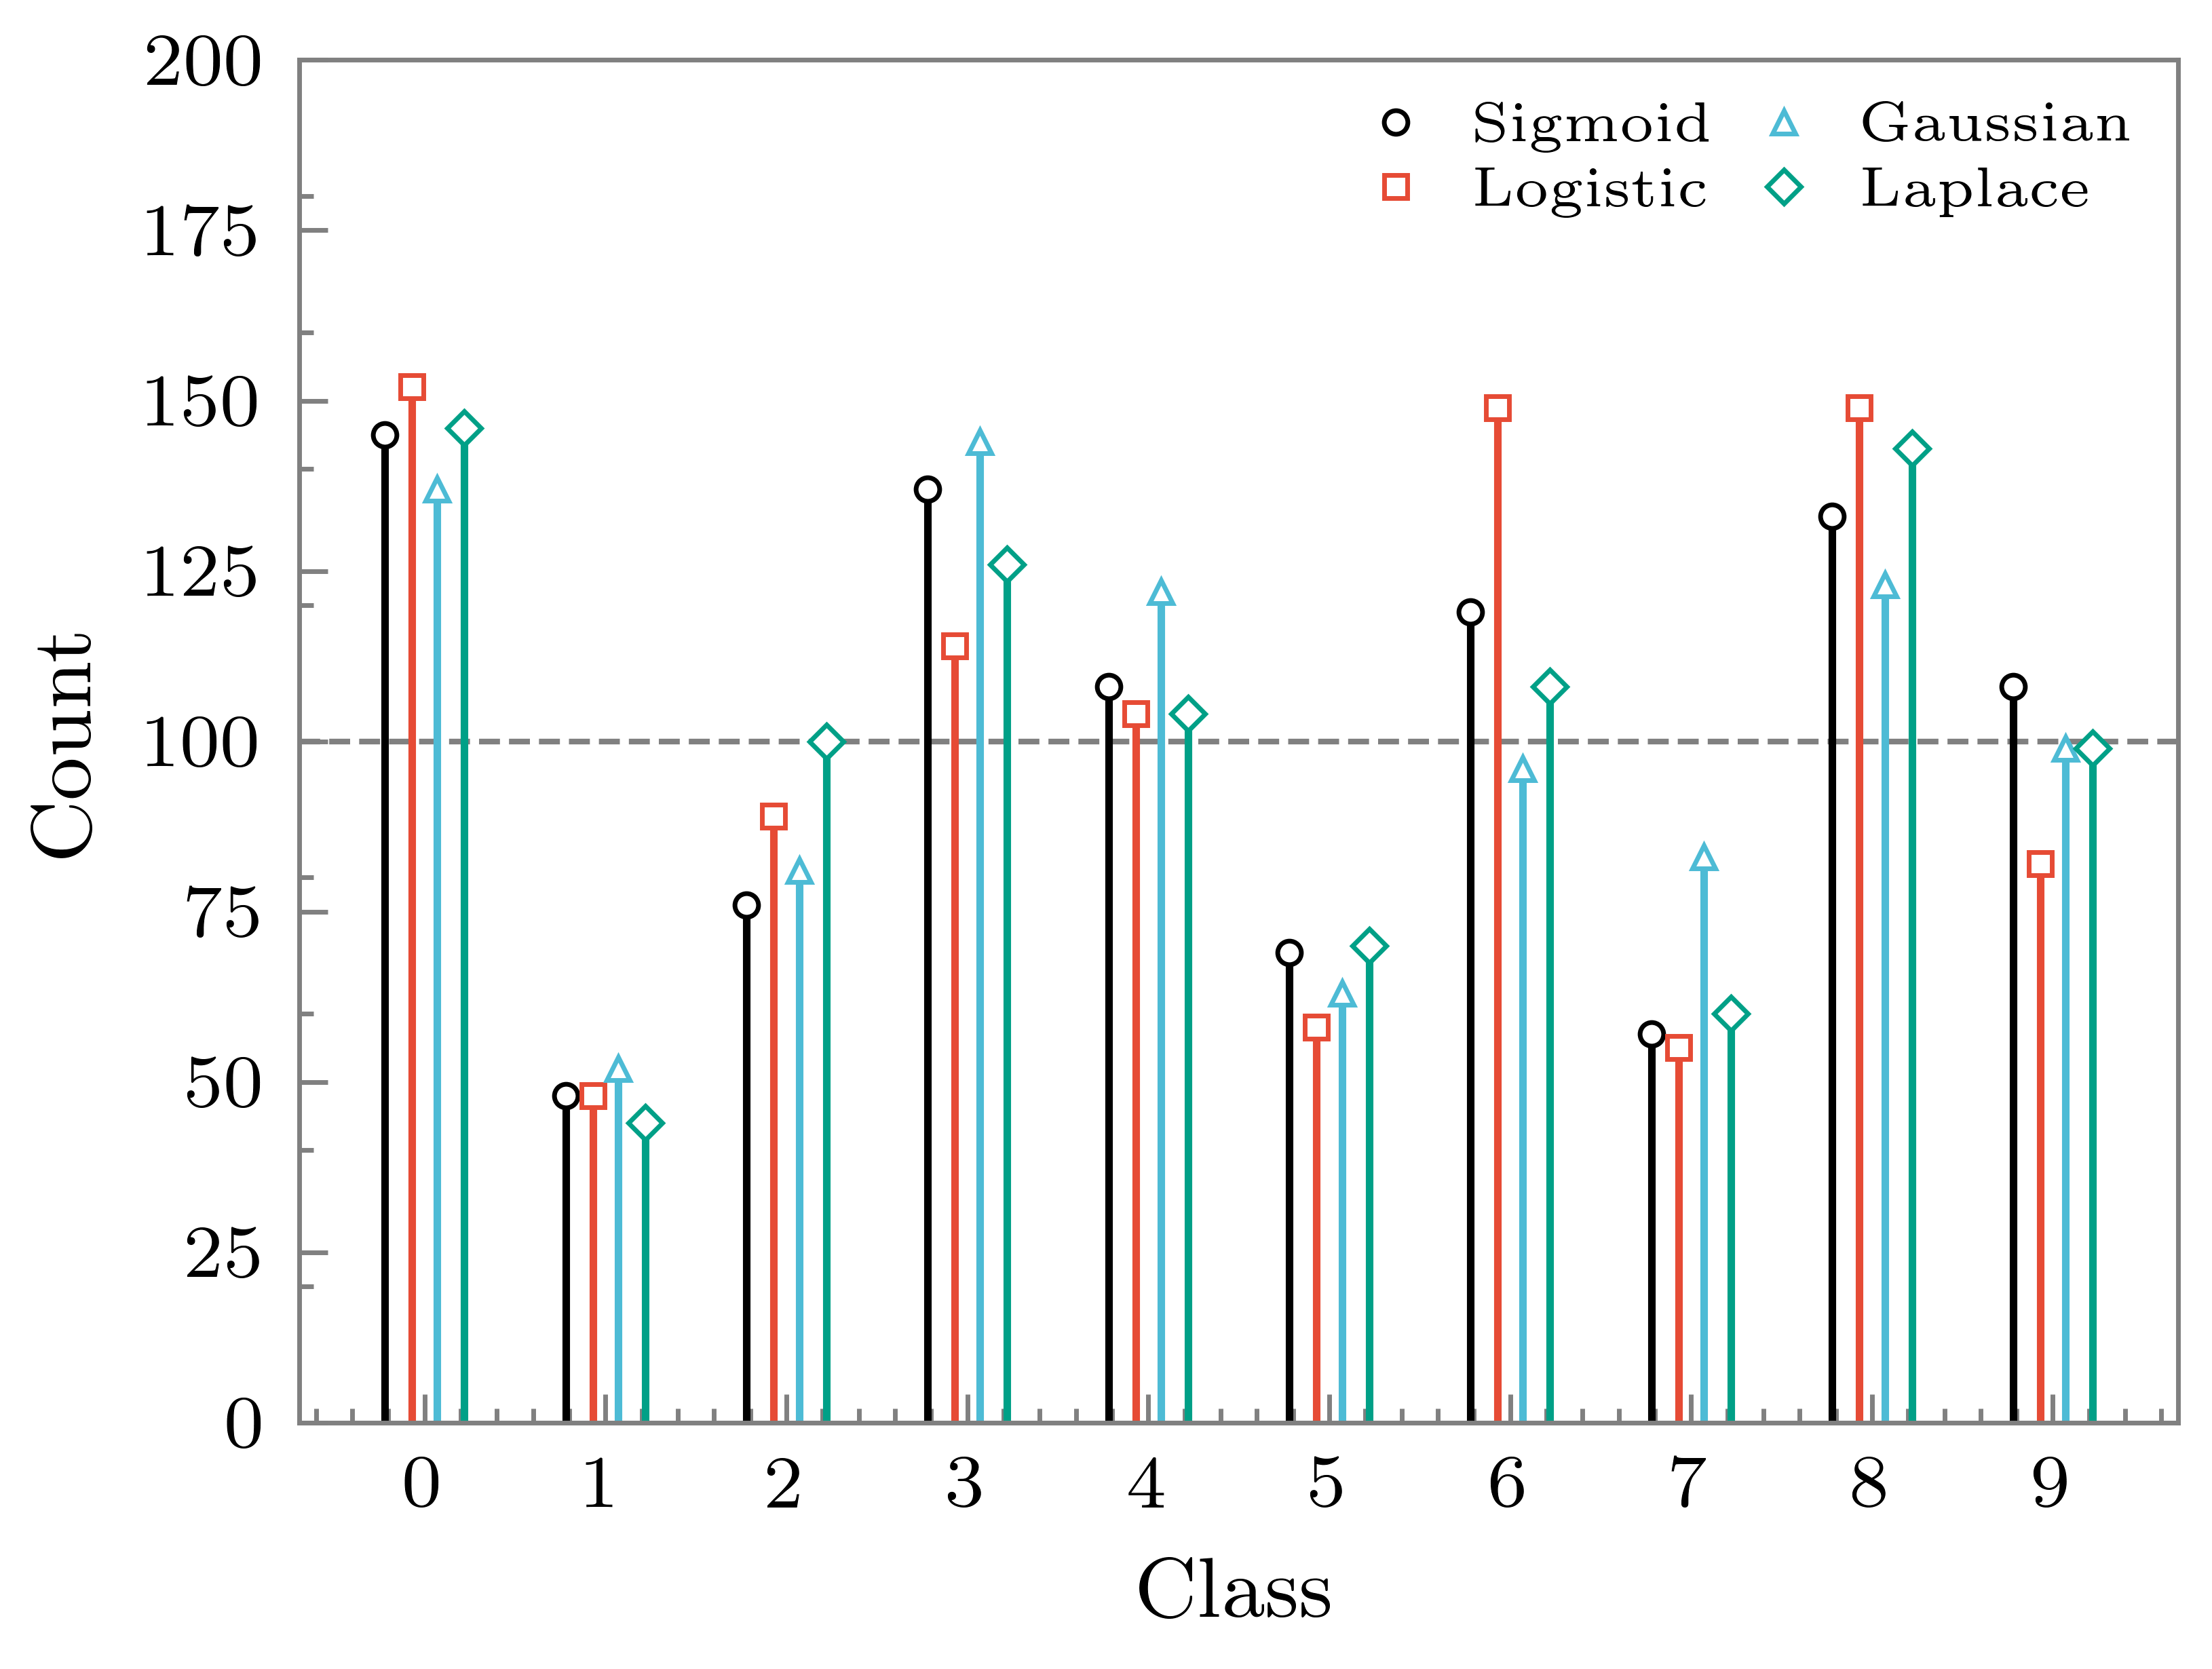

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scienceplots
from matplotlib.ticker import MultipleLocator

plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 1000
mpl.rcParams['axes.unicode_minus'] = False

BASE = "D:/PRE2023 2025/cifar10_revision_2026"

variants = {
    'Sigmoid':  f"{BASE}/logs_sigmoid/class_counts.npy",
    'Logistic': f"{BASE}/logs_logistic/class_counts.npy",
    'Gaussian': f"{BASE}/logs_gaussian/class_counts.npy",
    'Laplace':  f"{BASE}/logs_laplace/class_counts.npy",
}
counts = {k: np.load(v) for k, v in variants.items()}

labels  = list(counts.keys())
colors  = ['#000000', '#E64B35', '#4DBBD5', '#00A087']
markers = ['o', 's', '^', 'D']
offsets = [-0.22, -0.07, 0.07, 0.22]

x = np.arange(10)

fig, ax = plt.subplots(figsize=(3.4, 2.6))

for lab, col, mk, off in zip(labels, colors, markers, offsets):
    c = counts[lab]
    ax.vlines(x + off, 0, c, colors=col, linewidth=0.8, zorder=2)
    ax.plot(x + off, c, linestyle='None', marker=mk, color=col,
            markersize=2.5,
            markerfacecolor='white',
            markeredgecolor=col,
            markeredgewidth=0.5,
            zorder=3,
            label=lab)

ax.axhline(100, color='gray', linestyle='--', linewidth=0.6, zorder=1)

for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_color('gray')

ax.set_xlabel('Class', fontsize=9)
ax.set_ylabel('Count', fontsize=9)
ax.set_xticks(x)
ax.tick_params(axis='x', which='both', top=False, labelsize=8, width=0.5, color='gray')
ax.tick_params(axis='y', which='both', right=False, labelsize=8, width=0.5, color='gray')
ax.yaxis.set_minor_locator(MultipleLocator(20))
ax.set_ylim(0, 200)

ax.legend(fontsize=6, loc='upper right', frameon=False,
          handlelength=1.2, labelspacing=0.25, borderpad=0.25,
          ncol=2, columnspacing=0.6)

plt.tight_layout()
plt.savefig('D:/PRE2023 2025/Figcifarhist.eps', dpi=1000, bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


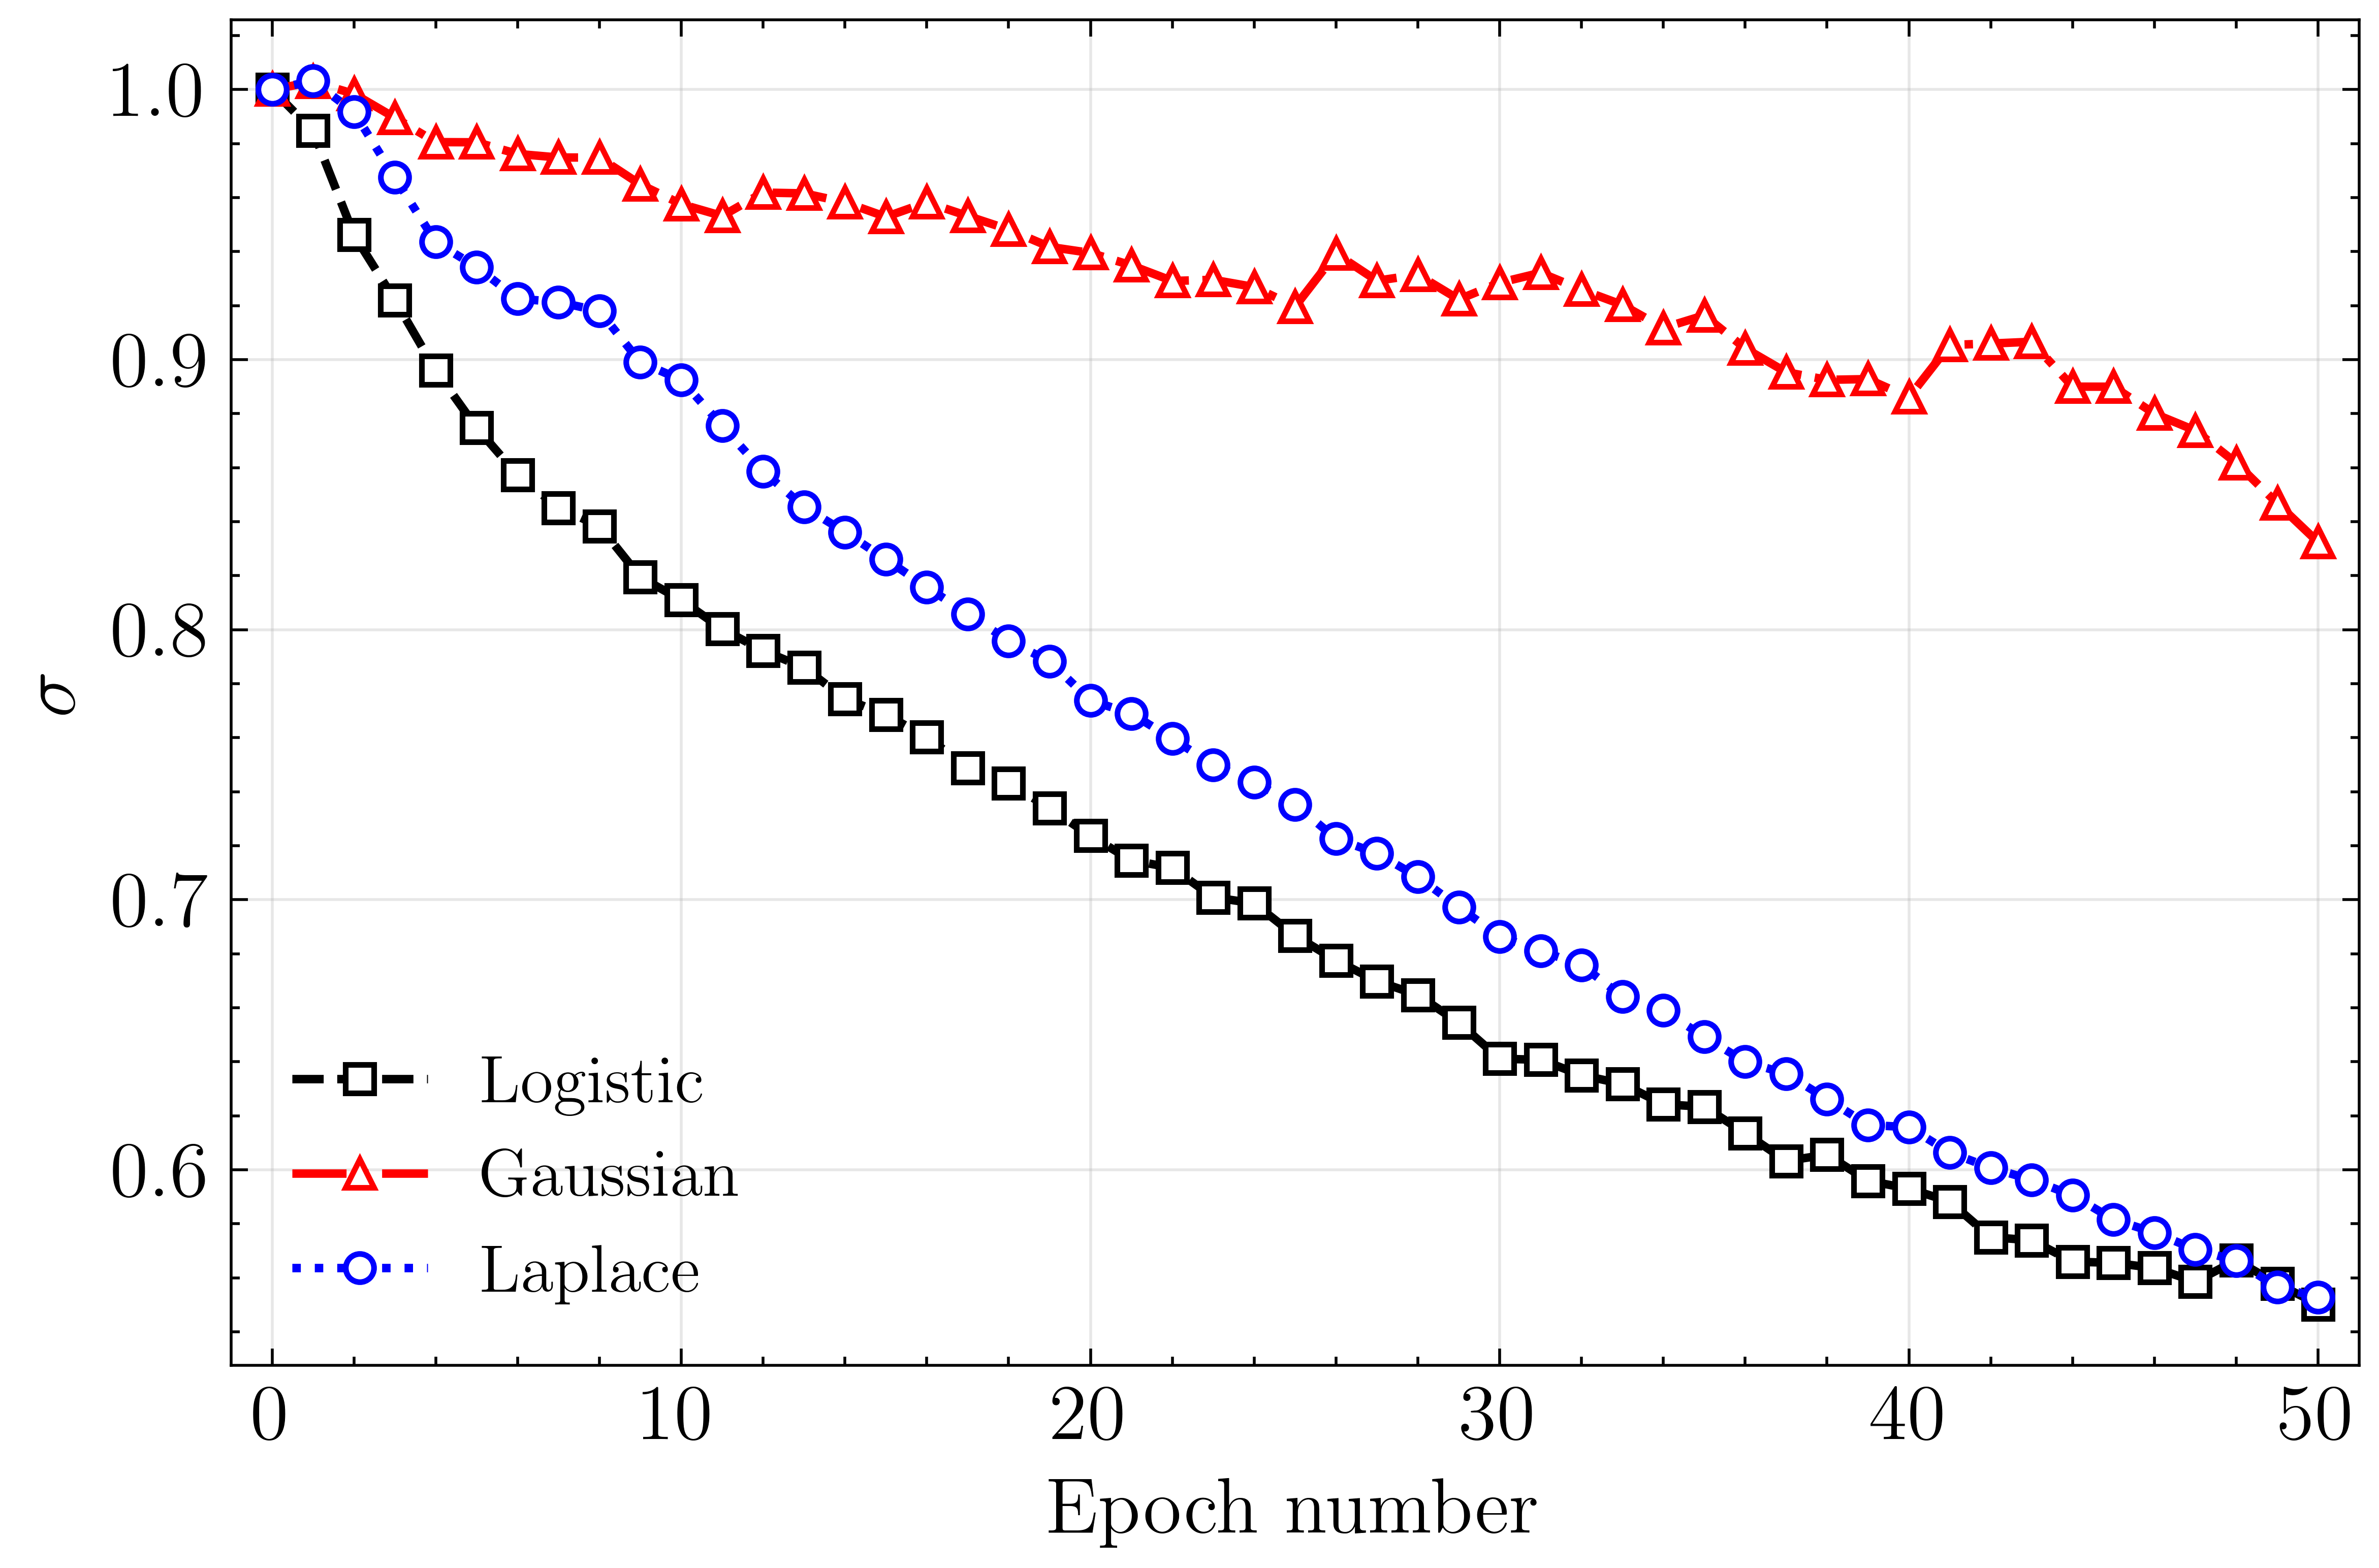

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import scienceplots

plt.style.use(['science', 'ieee'])
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False

BASE = "D:/PRE2023 2025/cifar10_revision_2026"

sigma_logistic = np.concatenate([[1.0], np.load(f"{BASE}/logs_logistic/epoch_sigma.npy")])
sigma_gaussian = np.concatenate([[1.0], np.load(f"{BASE}/logs_gaussian/epoch_sigma.npy")])
sigma_laplace  = np.concatenate([[1.0], np.load(f"{BASE}/logs_laplace/epoch_sigma.npy")])

plt.figure(figsize=(6, 4))

plt.plot(np.arange(len(sigma_logistic)), sigma_logistic,
         linewidth=1.5, color='k',
         marker='s', markersize=5, markerfacecolor='white',
         markeredgecolor='k', markeredgewidth=1.0,
         linestyle='--', label='Logistic')

plt.plot(np.arange(len(sigma_gaussian)), sigma_gaussian,
         linewidth=1.5, color='r',
         marker='^', markersize=5, markerfacecolor='white',
         markeredgecolor='r', markeredgewidth=1.0,
         linestyle='-.', label='Gaussian')

plt.plot(np.arange(len(sigma_laplace)), sigma_laplace,
         linewidth=1.5, color='b',
         marker='o', markersize=5, markerfacecolor='white',
         markeredgecolor='b', markeredgewidth=1.0,
         linestyle=':', label='Laplace')

plt.xlabel('Epoch number', fontsize=14)
plt.ylabel(r'$\sigma$', fontsize=14)
plt.xlim(-1, 51)
plt.xticks(range(0, 51, 10))
plt.tick_params(axis='both', which='major', labelsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12, loc='best')
plt.tight_layout()
plt.savefig('D:/PRE2025/Fig9.eps', format='eps', dpi=800, bbox_inches='tight')
plt.show()